# 3Di alignment benchmark

## Description

We compare the performance of ESM3Di, compared to ProstT5, on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* `AF3`: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* `ProstT5`: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* `ESM3Di`: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database, run Foldseek `structurealign` module with 1-vs-1 basis (aligning identical entries).

The results are represented as the bitscore of the alignment, and 3Di sequence identity, which can be calculated as: 
$\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}$

---

In [ ]:
# imports
import os
import sys
import shutil
import subprocess
import random
import shutil
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

# Ensure Foldseek is accessible before proceeding
if not shutil.which("foldseek"):
    raise RuntimeError(
        "Foldseek executable not found in PATH! "
        "Please load the foldseek module or install it via conda: `conda install -c bioconda foldseek`"
    )

print("Environment checks passed. Foldseek binary located.")

## Database preparation

### Download and process the MetaVR dataset

In [ ]:
DATAPATH = Path("../../mnt/data1/metavir_structs").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs


In [4]:
# count the number of files in the DATAPATH directory
directory = f"{DATAPATH}/metavr/metaVR_structures_all"
file_count = sum(1 for _ in Path(directory).glob('*') if _.is_file())
print(f"Number of files in {directory}: {file_count}")

Number of files in /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metaVR_structures_all: 7357


In [ ]:
def sample_structures(source_dir, output_dir, n_samples=500, seed=42):
    """Samples `n_samples` PDB/CIF files from source_dir into output_dir."""
    random.seed(seed)  # Fixed seed ensures reproducible sampling
    os.makedirs(output_dir, exist_ok=True)

    # Find all 3D structure files
    valid_exts = (".pdb", ".cif", ".ent", ".pdb.gz", ".cif.gz")
    all_files = [
        f
        for f in os.listdir(source_dir)
        if f.lower().endswith(valid_exts)
        and os.path.isfile(os.path.join(source_dir, f))
    ]

    if not all_files:
        print(f"Error: No structure files found in '{source_dir}'")
        return

    sample_size = min(n_samples, len(all_files))
    sampled_files = random.sample(all_files, sample_size)

    print(
        f"Found {len(all_files)} structure files in '{source_dir}'."
    )
    print(f"Copying {sample_size} files to '{output_dir}'...")

    for file_name in sampled_files:
        src = os.path.join(source_dir, file_name)
        dst = os.path.join(output_dir, file_name)
        shutil.copy2(src, dst)

    print(f"Done! Sampled {sample_size} structures successfully.\n")

In [7]:
sample_structures(directory, f"{DATAPATH}/metavr/metaVR_structures_100", n_samples=100, seed=42)

Found 7357 structure files in '/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metaVR_structures_all'.
Copying 100 files to '/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metaVR_structures_100'...
Done! Sampled 100 structures successfully.



### Ground trouth 3Di from AlphaFold3

In [8]:
%%bash
# Create Foldseek database
if [ -d "$DATAPATH/foldseek" ]; then
    rm -rf "$DATAPATH/foldseek"/*
else
    mkdir -p "$DATAPATH/foldseek"
fi

In [ ]:
%%bash
foldseek createdb "$DATAPATH/metavr/metaVR_structures_100" "$DATAPATH/foldseek/metavr_af3"

### Predict 3Di with ProstT5 (general purpose)

In [10]:
%%bash
awk '{gsub(/\x00/, "", $0)} NR==FNR{f[FNR]=$0; next} f[FNR]{print ">"f[FNR]"\n"$0}' \
	"$DATAPATH/foldseek/metavr_af3_h" \
	"$DATAPATH/foldseek/metavr_af3" \
	> "$DATAPATH/metavr/metavr_aa.fa"

grep -v "^>" "$DATAPATH/metavr/metavr_aa.fa" | wc -l

     100


In [14]:
%%bash
# 1. Ensure the destination directory exists
# mkdir -p "$DATAPATH/prostt5_weights"

# 2. Download the ProstT5 weights (Uncommented now)
# foldseek databases ProstT5 "$DATAPATH/prostt5_weights" "$DATAPATH/tmp"

# 3. Clean up temporary download cache
#rm -rf "$DATAPATH/tmp"

# 4. Create the Foldseek database using the downloaded weights
foldseek createdb "$DATAPATH/metavr/metavr_aa.fa" "$DATAPATH/foldseek/metavr_prostt5" --prostt5-model "$DATAPATH/prostt5_weights"

/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5 exists and will be overwritten
/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5 exists and will be overwritten
createdb /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_aa.fa /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5 --prostt5-model /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/prostt5_weights 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/prostt5_weights
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
F

### Predict 3Di with ESM3Di (Fine tuned for viral structure)

In [ ]:
%%bash

# for this to work I need to adjust the env in pyproject.toml (ipykernel, etc.)
# ran this from terminal with other env activated
esm3di foldseek-db \
  --input-fasta "$DATAPATH/metavr/metavr_aa.fa" \
  --output-db "$DATAPATH/metavr/foldseek/metavr_esm3di"

PosixPath('/Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs')

---

## Run Foldseek structure alignment

Now we have 3 Foldseek databases for the MetaVR dataset in `$DATAPATH/foldseek`:
 * `metavr_af3`: 3Di generated by Foldseek
 * `metavr_prostt5`: 3Di generated by ProstT5
 * `metavr_esm3di`: 3Di generated by ESM3Di

### Alignment (AF3 vs. ProstT5)

#### Generate fake prefilter database for 1-vs-1 alignment

In [16]:
%%bash
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
	"$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_prostt5_h" \
	> "$DATAPATH/metavr/metavr_prostt5_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_prostt5_pref.tsv" "$DATAPATH/foldseek/metavr_prostt5_pref" --output-dbtype 7

tsv2db /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_prostt5_pref.tsv /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5_pref --output-dbtype 7 

MMseqs Version:           	10.941cd33
Output database type      	7
Compressed                	0
Verbosity                 	3

Output database type: Prefilter
Time for merging to metavr_prostt5_pref: 0h 0m 0s 5ms
Time for processing: 0h 0m 0s 28ms


#### Run Foldseek alignment

In [17]:
%%bash
foldseek structurealign -e INF \
	"$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_prostt5_pref" "$DATAPATH/foldseek/metavr_prostt5_aln"

foldseek convertalis \
	"$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_prostt5_aln" "$DATAPATH/metavr/metavr_prostt5_aln.tsv"

structurealign -e INF /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_af3 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5_pref /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5_aln 

MMseqs Version:            	10.941cd33
TMscore threshold          	0
TMscore threshold mode     	0
LDDT threshold             	0
Sort by structure bit score	1
Alignment type             	2
Exact TMscore              	0
Substitution matrix        	aa:3di.out,nucl:3di.out
Add backtrace              	false
Alignment mode             	0
Alignment mode             	0
E-value threshold          	inf
Seq. id. threshold         	0
Min alignment length       	0
Seq. id. mode              	0
Alternative alignments     	0
Coverage threshold         	0
Coverage mode              	0
Max se

### Alignment (AF3 vs. ESM3Di)

In [18]:
%%bash
# Generate prefilter database
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
	"$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_esm3di_h" \
	> "$DATAPATH/metavr/metavr_esm3di_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_esm3di_pref.tsv" "$DATAPATH/foldseek/metavr_esm3di_pref" --output-dbtype 7

tsv2db /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_esm3di_pref.tsv /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref --output-dbtype 7 

MMseqs Version:           	10.941cd33
Output database type      	7
Compressed                	0
Verbosity                 	3

Output database type: Prefilter
Time for merging to metavr_esm3di_pref: 0h 0m 0s 1ms
Time for processing: 0h 0m 0s 8ms


In [19]:
%%bash
#output the number of lines in the prefilter file
wc -l "$DATAPATH/metavr/metavr_esm3di_pref.tsv"

wc -l "$DATAPATH/foldseek/metavr_esm3di_pref"

     100 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_esm3di_pref.tsv
     100 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref


In [20]:

%%bash
# Run Foldseek alignment
foldseek structurealign -e INF \
	"$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_esm3di_pref" "$DATAPATH/foldseek/metavr_esm3di_aln"

foldseek convertalis \
	"$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_esm3di_aln" "$DATAPATH/metavr/metavr_esm3di_aln.tsv"

structurealign -e INF /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_esm3di /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_af3 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_esm3di_aln 

MMseqs Version:            	10.941cd33
TMscore threshold          	0
TMscore threshold mode     	0
LDDT threshold             	0
Sort by structure bit score	1
Alignment type             	2
Exact TMscore              	0
Substitution matrix        	aa:3di.out,nucl:3di.out
Add backtrace              	false
Alignment mode             	0
Alignment mode             	0
E-value threshold          	inf
Seq. id. threshold         	0
Min alignment length       	0
Seq. id. mode              	0
Alternative alignments     	0
Coverage threshold         	0
Coverage mode              	0
Max seque

---

## Comparison of alignment scores

### Parse bitscores

In [21]:
%%bash
paste \
	<(cut -f1,12 "$DATAPATH/metavr/metavr_prostt5_aln.tsv" | sort) \
	<(cut -f1,12 "$DATAPATH/metavr/metavr_esm3di_aln.tsv" | sort | cut -f2) \
	> "$DATAPATH/metavr/metavr_bitscores.tsv"

#read number of lines in bitscores file
wc -l "$DATAPATH/metavr/metavr_bitscores.tsv"

     100 /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_bitscores.tsv


### Plot scores as a scatter plot

Number of points: 100


findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.


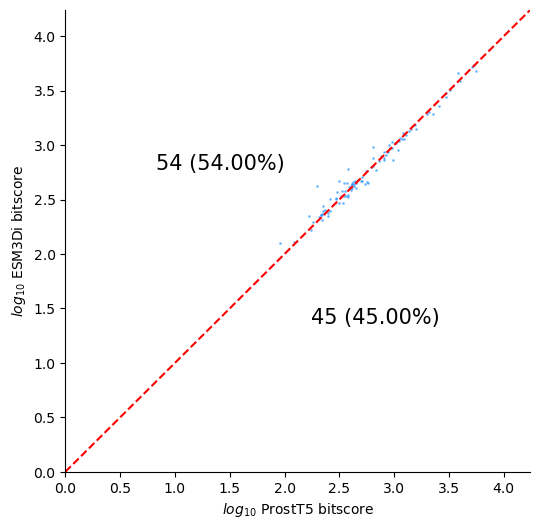

In [23]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_bitscores.tsv") as f:
	for line in f:
		identifier, prostt5_score, esm3di_score = line.strip().split()
		x.append(int(prostt5_score))
		y.append(int(esm3di_score))

print(f"Number of points: {len(x)}")



# take log
from math import log10
x = [0 if score <= 0 else log10(score) for score in x]
y = [0 if score <= 0 else log10(score) for score in y]

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# scatter plot
plt.scatter(x, y, alpha=0.5, s=1, color='dodgerblue')
plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/3, 2/3, txt_above, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)
ax.text(2/3, 1/3, txt_below, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('$log_{10}$ ProstT5 bitscore')
plt.ylabel('$log_{10}$ ESM3Di bitscore')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

---

## Identity calculation

### Generate 3Di FASTA files for each representation

In [24]:
%%bash
# AF3
foldseek base:lndb "$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_af3_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_af3_ss" "$DATAPATH/metavr/metavr_af3_3di.fa"

# ProstT5
foldseek base:lndb "$DATAPATH/foldseek/metavr_prostt5_h" "$DATAPATH/foldseek/metavr_prostt5_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_prostt5_ss" "$DATAPATH/metavr/metavr_prostt5_3di.fa"

# ESM3Di
foldseek base:lndb "$DATAPATH/foldseek/metavr_esm3di_h" "$DATAPATH/foldseek/metavr_esm3di_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_esm3di_ss" "$DATAPATH/metavr/metavr_esm3di_3di.fa"

lndb /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_af3_h /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_af3_ss_h 

MMseqs Version:	10.941cd33
Verbosity	3

Time for processing: 0h 0m 0s 9ms
convert2fasta /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_af3_ss /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_af3_3di.fa 

MMseqs Version:	10.941cd33
Use header DB	false
Verbosity    	3

Start writing file to /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/metavr/metavr_af3_3di.fa
Time for processing: 0h 0m 0s 11ms
lndb /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5_h /Users/finnweikert/Desktop/Dessimoz Lab/ESM3di/mnt/data1/metavir_structs/foldseek/metavr_prostt5_ss_h 

MMseqs Version:	10.941cd33
Verbosity	3

Time for processing: 0h 0m 0s 5ms
convert2fasta /

### Generate combined TSV file

In [25]:
%%bash
# Generate a TSV file with the following columns:
# [MetaVR ID], [AF3 3Di], [ProstT5 3Di], [ESM3Di 3Di]
paste \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_af3_3di.fa") \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_prostt5_3di.fa" | sort | cut -f2) \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_esm3di_3di.fa" | sort | cut -f2) \
	> "$DATAPATH/metavr/metavr_3di_comp.tsv"

# Ensure everything has equal length
awk 'length($2) != length($3) || length($2) != length($4) {print "Sanity check: ERROR"} END{print "Sanity check: OK"}' \
	"$DATAPATH/metavr/metavr_3di_comp.tsv"

Sanity check: OK


### Calculate 3Di identity

In [30]:
from pathlib import Path
import os

datapath = Path(os.environ["DATAPATH"])
outfile = open(datapath / "metavr/metavr_3di_identity.tsv", 'w')
with open(datapath / "metavr/metavr_3di_comp.tsv") as f:
	for line in f:
		metaVR_id, af3_3di, prostt5_3di, esm3di_3di = line.strip().split('\t')
		metaVR_id = metaVR_id[1:]  # remove '>' from FASTA header

		prostt5_identity = sum(a == b for a, b in zip(af3_3di, prostt5_3di)) / len(af3_3di) * 100
		esm3di_identity = sum(a == b for a, b in zip(af3_3di, esm3di_3di)) / len(af3_3di) * 100

		print(f'{metaVR_id}\t{prostt5_identity:.4f}\t{esm3di_identity:.4f}', file=outfile)
		x.append(prostt5_identity)
		y.append(esm3di_identity)

### Plot identity comparison as a density plot

findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Font family 'Nimbus sans' not found.
findfont: Fon

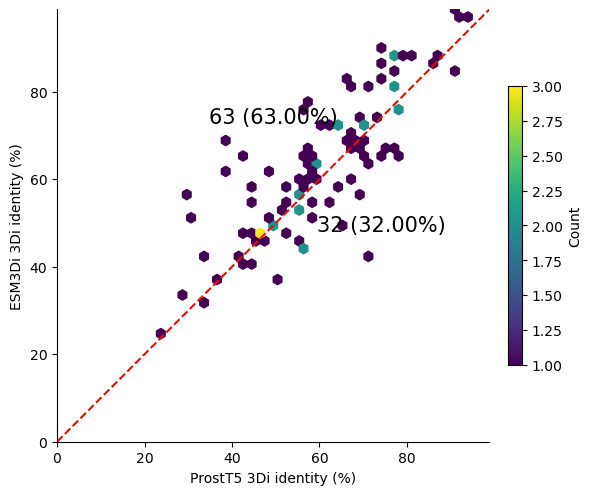

In [31]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_3di_identity.tsv") as f:
    for line in f:
        _, prostt5_identity, esm3di_identity = line.strip().split('\t')
        x.append(float(prostt5_identity))
        y.append(float(esm3di_identity))

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# density plot with viridis colormap
ax.set_aspect("equal", adjustable="box")   
hb = ax.hexbin(
    x, y,
    gridsize=50,
    extent=(0, lim, 0, lim),
    cmap="viridis",
    mincnt=1,
    #linewidths=0.0,
 )
hb.set_alpha(1)

# add colormap legend indicating the count of points in each hexbin
# make it much smaller
plt.colorbar(hb, ax=ax, label='Count', fraction=0.03, pad=0.04)

plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/2, 3/4, txt_above, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)
ax.text(3/4, 1/2, txt_below, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('ProstT5 3Di identity (%)')
plt.ylabel('ESM3Di 3Di identity (%)')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()